# Notebook 10 — Multi-Objective Pareto Optimization

## Goal

Notebook10 integrates the previous pipeline outputs into a multi-objective decision framework.

Earlier notebooks asked:

- Which clone is predicted to perform well?
- Which clone × process pair improves productivity or stability?
- Which clone × process pair preserves product quality?

Notebook10 asks:

> Which clone × process candidates are truly strong tradeoff options?

Instead of collapsing everything into one score immediately, this notebook identifies Pareto-optimal candidates.

A Pareto-optimal candidate is a candidate that is not clearly worse than another candidate across all major objectives.

## Objectives

We evaluate each clone × process candidate across:

1. Productivity
2. Stability
3. Product quality
4. Process risk
5. Rescue value

This notebook helps separate:

- clearly inferior candidates
- high-productivity but risky candidates
- lower-productivity but high-quality candidates
- balanced manufacturing candidates
- rescue candidates worth further process development

## Section 1 — Imports and load Notebook09 outputs

Notebook10 uses Notebook09 outputs as the main input.

The key file is:

`notebook09_quality_simulation_5000_legacy.csv`

This file contains clone × process quality simulation results.

In [1]:
# --------------------------------------------------
# Section 1 — Imports and load inputs
# --------------------------------------------------

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


def find_project_root(start=None):
    if start is None:
        start = Path.cwd().resolve()
    start = Path(start).resolve()

    for p in [start, *start.parents]:
        if (p / "data" / "synthetic").exists():
            return p

    raise FileNotFoundError("Could not find project root containing data/synthetic")


ROOT = find_project_root()

scenario = "legacy"
n_clones = 5000

QUALITY_PATH = (
    ROOT
    / "data"
    / "synthetic"
    / "quality"
    / f"notebook09_quality_simulation_{n_clones}_{scenario}.csv"
)

print("ROOT:", ROOT)
print("QUALITY_PATH:", QUALITY_PATH)

quality_df = pd.read_csv(QUALITY_PATH)

print("quality_df:", quality_df.shape)
display(quality_df.head())

ROOT: /Users/sang/CLD_ML_PIPELINE
QUALITY_PATH: /Users/sang/CLD_ML_PIPELINE/data/synthetic/quality/notebook09_quality_simulation_5000_legacy.csv
quality_df: (8000, 31)


,clone_id,process_condition,baseline_quality_score,process_quality_score,quality_score_gain,glycan_maturity,process_glycan_maturity,galactosylation_level,process_galactosylation_level,sialylation_capacity,...,pred_late_agg,pred_rescue_score,pred_rescue_label,is_aggressive,is_super,quality_pass,quality_risk_flag,production_score,combined_quality_utility,combined_quality_utility_guarded
0,CLONE_1502,baseline,0.926955,0.926955,0.000000,0.960779,0.960779,0.672009,0.672009,0.777812,...,9.583127,0.598822,1,0,0,True,PASS,-0.783991,-0.099612,-0.099612
1,CLONE_1502,rich_media,0.926955,0.881629,-0.045326,0.960779,0.968112,0.672009,0.700880,0.777812,...,9.583127,0.598822,1,0,0,True,PASS,-0.783991,-0.117743,-0.117743
2,CLONE_1502,balanced_feed,0.926955,1.092353,0.165398,0.960779,1.000000,0.672009,0.712253,0.777812,...,9.583127,0.598822,1,0,0,True,PASS,-0.783991,-0.033453,-0.033453
3,CLONE_1502,nutrient_limited,0.926955,1.038956,0.112001,0.960779,0.985033,0.672009,0.663833,0.777812,...,9.583127,0.598822,1,0,0,True,PASS,-0.783991,-0.054812,-0.054812
4,CLONE_1502,mild_temp_shift,0.926955,1.115908,0.188953,0.960779,1.000000,0.672009,0.696539,0.777812,...,9.583127,0.598822,1,0,0,True,PASS,-0.783991,-0.024031,-0.024031


## Section 2 — Define multi-objective decision variables

For Pareto optimization, all objectives should point in the same direction.

In this notebook:

Higher is better for:

- productivity objective
- stability objective
- quality objective
- rescue objective

Lower is better for risk, so we convert it into:

- risk safety objective

This means every objective can be interpreted as:

> higher value = more desirable

In [2]:
# --------------------------------------------------
# Section 2 — Define objective variables
# --------------------------------------------------

def z01(s):
    s = pd.Series(s).astype(float)
    return (s - s.min()) / (s.max() - s.min() + 1e-12)


work = quality_df.copy()

# Productivity objective
work["obj_productivity"] = z01(work["pred_late_qp"])

# Stability objective
# Lower qP drop is better, so invert it.
work["obj_stability"] = 1.0 - z01(work["pred_qp_drop"])

# Product quality objective
work["obj_quality"] = z01(work["process_quality_score"])

# Risk safety objective
# Lower mannose, aggregation, and quality stress are better.
risk_raw = (
    0.40 * z01(work["process_mannose_retention_risk"])
    + 0.40 * z01(work["process_aggregation_propensity"])
    + 0.20 * z01(work["stress_penalty"].clip(lower=0))
)

work["obj_risk_safety"] = 1.0 - z01(risk_raw)

# Rescue value objective
# Rescue-labeled clones receive value, but only if quality passes.
work["obj_rescue_value"] = (
    z01(work["pred_rescue_score"])
    * work["quality_pass"].astype(float)
)

objective_cols = [
    "obj_productivity",
    "obj_stability",
    "obj_quality",
    "obj_risk_safety",
    "obj_rescue_value",
]

display(work[objective_cols].describe())

,obj_productivity,obj_stability,obj_quality,obj_risk_safety,obj_rescue_value
count,8000.000000,8.000000e+03,8000.000000,8.000000e+03,8000.000000
mean,0.026175,7.143410e-01,0.592792,6.882911e-01,0.242137
std,0.080090,1.541266e-01,0.152451,1.389899e-01,0.220414
min,0.000000,1.467715e-12,0.000000,1.019518e-12,0.000000
25%,0.003786,6.610022e-01,0.487912,6.008677e-01,0.000000
50%,0.010020,7.531465e-01,0.602690,6.974892e-01,0.300991
75%,0.023855,8.198710e-01,0.701811,7.888334e-01,0.405683
max,1.000000,1.000000e+00,1.000000,1.000000e+00,1.000000


## Section 3 — Apply minimum feasibility guardrails

Before Pareto optimization, we remove candidates that fail basic feasibility requirements.

This prevents poor-quality or highly unstable candidates from appearing on the Pareto frontier only because they are strong in one objective.

Current feasibility rules:

- quality must pass
- predicted qP drop should not be too high
- predicted late aggregation should not be too high

In [3]:
# --------------------------------------------------
# Section 3 — Feasibility guardrails
# --------------------------------------------------

feasible = work[
    (work["quality_pass"])
    &
    (work["pred_qp_drop"] <= 0.65)
    &
    (work["pred_late_agg"] <= 18.0)
].copy()

print("All clone-process pairs:", len(work))
print("Feasible clone-process pairs:", len(feasible))
print("Feasible rate:", round(len(feasible) / len(work), 4))

display(
    feasible[
        [
            "clone_id",
            "process_condition",
            "pred_late_qp",
            "pred_qp_drop",
            "pred_late_agg",
            "process_quality_score",
            "quality_pass",
        ]
    ].head()
)

All clone-process pairs: 8000
Feasible clone-process pairs: 4615
Feasible rate: 0.5769


,clone_id,process_condition,pred_late_qp,pred_qp_drop,pred_late_agg,process_quality_score,quality_pass
0,CLONE_1502,baseline,2.711177e-08,0.381373,9.583127,0.926955,True
1,CLONE_1502,rich_media,2.711177e-08,0.381373,9.583127,0.881629,True
2,CLONE_1502,balanced_feed,2.711177e-08,0.381373,9.583127,1.092353,True
3,CLONE_1502,nutrient_limited,2.711177e-08,0.381373,9.583127,1.038956,True
4,CLONE_1502,mild_temp_shift,2.711177e-08,0.381373,9.583127,1.115908,True


## Section 4 — Pareto frontier calculation

A candidate is Pareto-optimal if no other candidate is better across all objectives.

Candidate A dominates Candidate B if:

- A is at least as good as B in every objective
- and A is strictly better in at least one objective

After this step, Pareto candidates represent non-dominated tradeoff options.

In [4]:
# --------------------------------------------------
# Section 4 — Pareto frontier calculation
# --------------------------------------------------

def pareto_frontier_mask(values):
    """
    Return boolean mask where True indicates Pareto-optimal rows.

    values:
        numpy array with shape (n_candidates, n_objectives)
        Higher values are better for every objective.
    """
    values = np.asarray(values, dtype=float)
    n = values.shape[0]

    is_pareto = np.ones(n, dtype=bool)

    for i in range(n):
        if not is_pareto[i]:
            continue

        # A row is dominated if another row is >= in all objectives
        # and > in at least one objective.
        dominates_i = (
            np.all(values >= values[i], axis=1)
            &
            np.any(values > values[i], axis=1)
        )

        if np.any(dominates_i):
            is_pareto[i] = False

    return is_pareto


X = feasible[objective_cols].to_numpy()

feasible["is_pareto"] = pareto_frontier_mask(X)

pareto_df = feasible[feasible["is_pareto"]].copy()

print("Pareto candidates:", len(pareto_df))
print("Pareto rate among feasible:", round(len(pareto_df) / len(feasible), 4))

display(
    pareto_df[
        [
            "clone_id",
            "process_condition",
            *objective_cols,
            "pred_late_qp",
            "pred_qp_drop",
            "pred_late_agg",
            "process_quality_score",
            "quality_pass",
            "pred_rescue_label",
            "pred_rescue_score",
        ]
    ]
    .sort_values("obj_quality", ascending=False)
    .head(20)
)

Pareto candidates: 92
Pareto rate among feasible: 0.0199


,clone_id,process_condition,obj_productivity,obj_stability,obj_quality,obj_risk_safety,obj_rescue_value,pred_late_qp,pred_qp_drop,pred_late_agg,process_quality_score,quality_pass,pred_rescue_label,pred_rescue_score
7410,CLONE_3895,balanced_feed,0.011834,0.822675,0.989642,0.983893,0.388383,8.950082e-08,0.363346,4.486685,1.415354,True,0,0.388383
7412,CLONE_3895,mild_temp_shift,0.011834,0.822675,0.986077,1.000000,0.388383,8.950082e-08,0.363346,4.486685,1.403792,True,0,0.388383
1342,CLONE_1591,stress_minimized,0.044902,0.831750,0.977254,0.889394,0.406233,2.718107e-07,0.357162,4.642763,1.375178,True,0,0.406233
3174,CLONE_1633,stress_minimized,0.004068,0.847920,0.933438,0.963826,0.386914,4.668606e-08,0.346146,4.569337,1.233079,True,0,0.386914
2782,CLONE_3007,stress_minimized,0.000540,0.992249,0.926534,0.967398,0.264918,2.723450e-08,0.247811,6.409449,1.210689,True,0,0.264918
7046,CLONE_1719,stress_minimized,0.009126,0.730606,0.921844,0.998086,0.390770,7.457335e-08,0.426074,5.734888,1.195478,True,0,0.390770
414,CLONE_4629,stress_minimized,0.002297,0.845998,0.912493,0.934216,0.389808,3.692393e-08,0.347455,4.012363,1.165152,True,0,0.389808
1582,CLONE_2806,stress_minimized,0.014327,0.759018,0.910595,0.917332,0.351405,1.032451e-07,0.406716,4.252140,1.158996,True,0,0.351405
6638,CLONE_3546,stress_minimized,0.000746,0.840622,0.910127,0.876570,0.566541,2.837192e-08,0.351118,10.585921,1.157476,True,0,0.566541
5894,CLONE_0319,stress_minimized,0.000132,0.645430,0.910089,0.962933,0.511694,2.498445e-08,0.484106,8.124833,1.157354,True,0,0.511694


## Section 5 — Weighted utility score for Pareto candidates

Pareto optimization gives us a set of non-dominated candidates.

However, we still need a practical ranking for review.

This section calculates a weighted utility score only among feasible candidates.

The weighted score is not a replacement for Pareto optimization.

It is a practical prioritization layer.

In [5]:
# --------------------------------------------------
# Section 5 — Weighted utility ranking
# --------------------------------------------------

weights = {
    "obj_productivity": 0.30,
    "obj_stability": 0.20,
    "obj_quality": 0.25,
    "obj_risk_safety": 0.15,
    "obj_rescue_value": 0.10,
}

feasible["weighted_multiobj_score"] = sum(
    weights[c] * feasible[c] for c in weights
)

pareto_df = feasible[feasible["is_pareto"]].copy()

pareto_df["weighted_multiobj_score"] = sum(
    weights[c] * pareto_df[c] for c in weights
)

pareto_df["pareto_rank"] = pareto_df["weighted_multiobj_score"].rank(
    ascending=False,
    method="dense",
)

display(
    pareto_df[
        [
            "clone_id",
            "process_condition",
            "pareto_rank",
            "weighted_multiobj_score",
            *objective_cols,
            "pred_late_qp",
            "pred_qp_drop",
            "pred_late_agg",
            "process_quality_score",
            "quality_pass",
            "pred_rescue_label",
            "pred_rescue_score",
        ]
    ]
    .sort_values("weighted_multiobj_score", ascending=False)
    .head(30)
)

,clone_id,process_condition,pareto_rank,weighted_multiobj_score,obj_productivity,obj_stability,obj_quality,obj_risk_safety,obj_rescue_value,pred_late_qp,pred_qp_drop,pred_late_agg,process_quality_score,quality_pass,pred_rescue_label,pred_rescue_score
1446,CLONE_4625,stress_minimized,1.0,0.832599,1.000000,0.830653,0.698502,0.612287,1.000000,5.537450e-06,0.357910,8.834887,0.471150,True,1,1.000000
5846,CLONE_4878,stress_minimized,2.0,0.730900,0.796817,0.692042,0.663813,0.731984,0.776958,4.417263e-06,0.452348,10.140637,0.358650,True,1,0.776958
7412,CLONE_3895,mild_temp_shift,3.0,0.603442,0.011834,0.822675,0.986077,1.000000,0.388383,8.950082e-08,0.363346,4.486685,1.403792,True,0,0.388383
7410,CLONE_3895,balanced_feed,4.0,0.601918,0.011834,0.822675,0.989642,0.983893,0.388383,8.950082e-08,0.363346,4.486685,1.415354,True,0,0.388383
2782,CLONE_3007,stress_minimized,5.0,0.601847,0.000540,0.992249,0.926534,0.967398,0.264918,2.723450e-08,0.247811,6.409449,1.210689,True,0,0.264918
5670,CLONE_3527,stress_minimized,6.0,0.600009,0.027291,0.860488,0.857805,0.930117,0.657553,1.747197e-07,0.337582,8.556851,0.987790,True,1,0.657553
1342,CLONE_1591,stress_minimized,7.0,0.598166,0.044902,0.831750,0.977254,0.889394,0.406233,2.718107e-07,0.357162,4.642763,1.375178,True,0,0.406233
2462,CLONE_2827,stress_minimized,8.0,0.595797,0.013267,0.898510,0.857233,0.956732,0.542968,9.740045e-08,0.311677,9.482413,0.985934,True,0,0.542968
2204,CLONE_3249,mild_temp_shift,9.0,0.592651,0.030278,0.881808,0.893316,1.000000,0.338768,1.911850e-07,0.323057,3.103373,1.102957,True,0,0.338768
5310,CLONE_1045,stress_minimized,10.0,0.589655,0.043214,0.859718,0.856026,0.918783,0.529228,2.625069e-07,0.338107,6.778770,0.982022,True,0,0.529228


## Section 6 — Candidate archetype labeling

Pareto candidates can be strong for different reasons.

This section assigns simple archetypes:

- Productivity-led
- Quality-led
- Stability-led
- Risk-safe
- Rescue-value
- Balanced

This helps interpret the Pareto frontier in scientist-readable terms.

In [6]:
# --------------------------------------------------
# Section 6 — Candidate archetype labeling
# --------------------------------------------------

def assign_archetype(row):
    objectives = {
        "Productivity-led": row["obj_productivity"],
        "Stability-led": row["obj_stability"],
        "Quality-led": row["obj_quality"],
        "Risk-safe": row["obj_risk_safety"],
        "Rescue-value": row["obj_rescue_value"],
    }

    top_label = max(objectives, key=objectives.get)
    top_value = objectives[top_label]

    spread = np.std(list(objectives.values()))

    if spread < 0.12:
        return "Balanced"

    if top_value >= 0.75:
        return top_label

    return "Mixed"


pareto_df["candidate_archetype"] = pareto_df.apply(assign_archetype, axis=1)

archetype_summary = (
    pareto_df
    .groupby("candidate_archetype")
    .size()
    .reset_index(name="n_candidates")
    .sort_values("n_candidates", ascending=False)
)

display(archetype_summary)

display(
    pareto_df[
        [
            "clone_id",
            "process_condition",
            "candidate_archetype",
            "weighted_multiobj_score",
            *objective_cols,
            "pred_rescue_label",
            "pred_rescue_score",
        ]
    ]
    .sort_values("weighted_multiobj_score", ascending=False)
    .head(30)
)

,candidate_archetype,n_candidates
5,Stability-led,40
4,Risk-safe,36
2,Quality-led,11
1,Mixed,3
0,Balanced,1
3,Rescue-value,1


,clone_id,process_condition,candidate_archetype,weighted_multiobj_score,obj_productivity,obj_stability,obj_quality,obj_risk_safety,obj_rescue_value,pred_rescue_label,pred_rescue_score
1446,CLONE_4625,stress_minimized,Rescue-value,0.832599,1.000000,0.830653,0.698502,0.612287,1.000000,1,1.000000
5846,CLONE_4878,stress_minimized,Balanced,0.730900,0.796817,0.692042,0.663813,0.731984,0.776958,1,0.776958
7412,CLONE_3895,mild_temp_shift,Risk-safe,0.603442,0.011834,0.822675,0.986077,1.000000,0.388383,0,0.388383
7410,CLONE_3895,balanced_feed,Quality-led,0.601918,0.011834,0.822675,0.989642,0.983893,0.388383,0,0.388383
2782,CLONE_3007,stress_minimized,Stability-led,0.601847,0.000540,0.992249,0.926534,0.967398,0.264918,0,0.264918
5670,CLONE_3527,stress_minimized,Risk-safe,0.600009,0.027291,0.860488,0.857805,0.930117,0.657553,1,0.657553
1342,CLONE_1591,stress_minimized,Quality-led,0.598166,0.044902,0.831750,0.977254,0.889394,0.406233,0,0.406233
2462,CLONE_2827,stress_minimized,Risk-safe,0.595797,0.013267,0.898510,0.857233,0.956732,0.542968,0,0.542968
2204,CLONE_3249,mild_temp_shift,Risk-safe,0.592651,0.030278,0.881808,0.893316,1.000000,0.338768,0,0.338768
5310,CLONE_1045,stress_minimized,Risk-safe,0.589655,0.043214,0.859718,0.856026,0.918783,0.529228,0,0.529228


## Section 7 — Process condition enrichment on the Pareto frontier

This section checks which process conditions appear most often among Pareto candidates.

If one process dominates the frontier, it may be too strong.

If multiple processes appear, the simulation is showing meaningful process tradeoffs.

In [7]:
# --------------------------------------------------
# Section 7 — Process enrichment among Pareto candidates
# --------------------------------------------------

process_counts = (
    pareto_df
    .groupby("process_condition")
    .size()
    .reset_index(name="pareto_count")
)

process_total = (
    feasible
    .groupby("process_condition")
    .size()
    .reset_index(name="feasible_count")
)

process_enrichment = process_counts.merge(
    process_total,
    on="process_condition",
    how="right",
).fillna(0)

process_enrichment["pareto_rate"] = (
    process_enrichment["pareto_count"]
    / process_enrichment["feasible_count"]
)

process_enrichment = process_enrichment.sort_values(
    "pareto_rate",
    ascending=False,
)

display(process_enrichment)

,process_condition,pareto_count,feasible_count,pareto_rate
7,stress_minimized,89.0,647,0.137558
3,mild_temp_shift,2.0,632,0.003165
1,balanced_feed,1.0,588,0.001701
0,adaptive_perfusion,0.0,605,0.000000
2,baseline,0.0,494,0.000000
4,nutrient_limited,0.0,590,0.000000
5,perfusion_like,0.0,619,0.000000
6,rich_media,0.0,440,0.000000


## Section 8 — Rescue representation on the Pareto frontier

This section checks whether rescue-labeled clones appear on the Pareto frontier.

This is important because we want to know whether rescue candidates remain useful after adding quality and risk objectives.

A good result is not necessarily many rescue clones.

A good result is:

> some rescue candidates survive as meaningful tradeoff options.

In [8]:
# --------------------------------------------------
# Section 8 — Rescue representation
# --------------------------------------------------

rescue_summary = (
    pareto_df
    .groupby("pred_rescue_label")
    .agg(
        n_candidates=("clone_id", "count"),
        mean_score=("weighted_multiobj_score", "mean"),
        mean_productivity=("obj_productivity", "mean"),
        mean_quality=("obj_quality", "mean"),
        mean_risk_safety=("obj_risk_safety", "mean"),
        mean_rescue_value=("obj_rescue_value", "mean"),
    )
    .reset_index()
)

display(rescue_summary)

print("Note:")
print("pred_rescue_label = 0 means non-rescue candidates")
print("pred_rescue_label = 1 means rescue-labeled candidates")

,pred_rescue_label,n_candidates,mean_score,mean_productivity,mean_quality,mean_risk_safety,mean_rescue_value
0,0,75,0.539598,0.044653,0.769351,0.840731,0.421455
1,1,17,0.562453,0.145038,0.687269,0.783253,0.660397


Note:
pred_rescue_label = 0 means non-rescue candidates
pred_rescue_label = 1 means rescue-labeled candidates


## Section 9 — Visualization of Pareto tradeoffs

This section visualizes the Pareto frontier.

We focus on:

- productivity vs quality
- stability vs quality
- risk safety vs productivity

Pareto candidates are highlighted separately from feasible non-Pareto candidates.

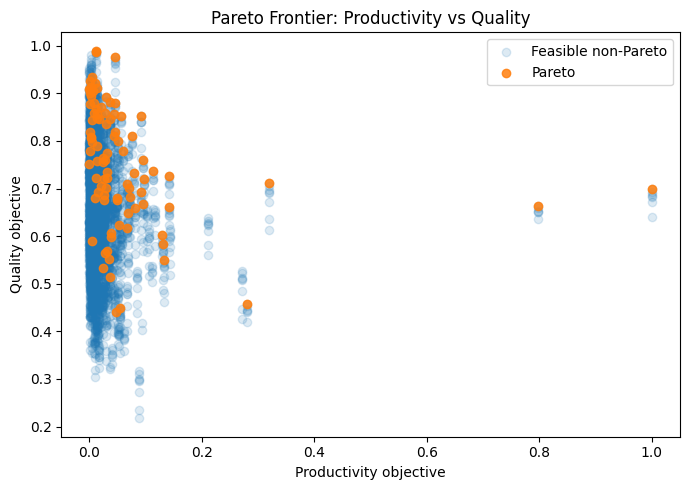

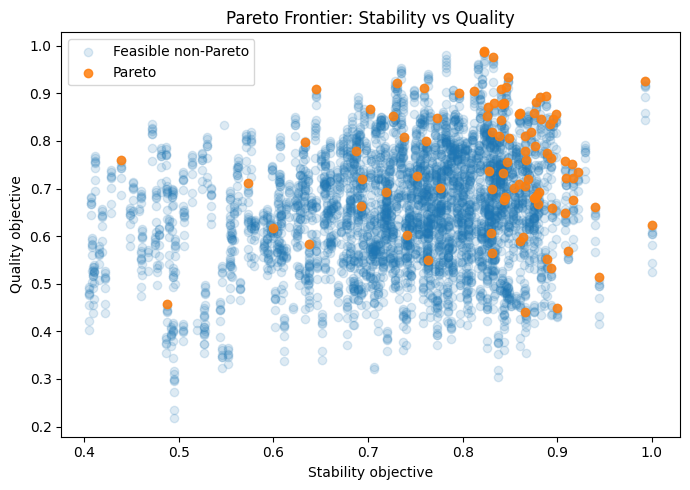

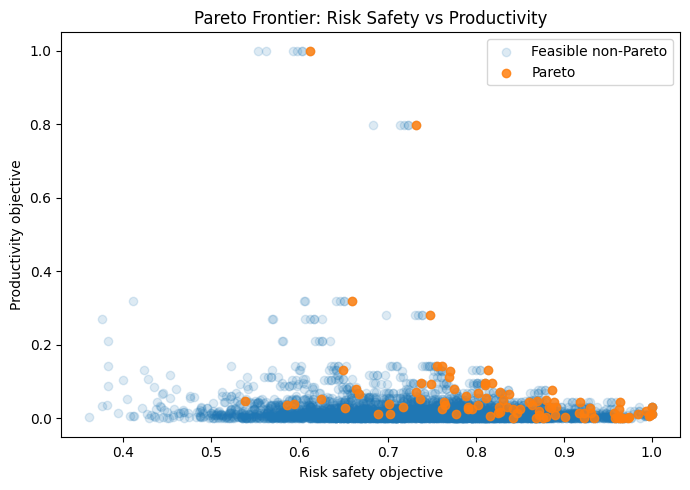

In [9]:
# --------------------------------------------------
# Section 9 — Visualization
# --------------------------------------------------

plt.figure(figsize=(7, 5))
plt.scatter(
    feasible["obj_productivity"],
    feasible["obj_quality"],
    alpha=0.15,
    label="Feasible non-Pareto",
)
plt.scatter(
    pareto_df["obj_productivity"],
    pareto_df["obj_quality"],
    alpha=0.85,
    label="Pareto",
)
plt.title("Pareto Frontier: Productivity vs Quality")
plt.xlabel("Productivity objective")
plt.ylabel("Quality objective")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 5))
plt.scatter(
    feasible["obj_stability"],
    feasible["obj_quality"],
    alpha=0.15,
    label="Feasible non-Pareto",
)
plt.scatter(
    pareto_df["obj_stability"],
    pareto_df["obj_quality"],
    alpha=0.85,
    label="Pareto",
)
plt.title("Pareto Frontier: Stability vs Quality")
plt.xlabel("Stability objective")
plt.ylabel("Quality objective")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 5))
plt.scatter(
    feasible["obj_risk_safety"],
    feasible["obj_productivity"],
    alpha=0.15,
    label="Feasible non-Pareto",
)
plt.scatter(
    pareto_df["obj_risk_safety"],
    pareto_df["obj_productivity"],
    alpha=0.85,
    label="Pareto",
)
plt.title("Pareto Frontier: Risk Safety vs Productivity")
plt.xlabel("Risk safety objective")
plt.ylabel("Productivity objective")
plt.legend()
plt.tight_layout()
plt.show()

## Section 10 — Final candidate recommendation table

This section creates a compact final recommendation table.

The table includes:

- clone ID
- process condition
- Pareto rank
- archetype
- objective scores
- productivity / stability / quality readouts
- rescue label
- interpretation-ready recommendation

In [10]:
# --------------------------------------------------
# Section 10 — Final recommendation table
# --------------------------------------------------

def recommendation_text(row):
    archetype = row["candidate_archetype"]

    if archetype == "Productivity-led":
        return "High-productivity Pareto candidate; confirm quality robustness experimentally."

    if archetype == "Quality-led":
        return "Quality-led Pareto candidate; useful when product quality is prioritized."

    if archetype == "Stability-led":
        return "Stability-led Pareto candidate; useful for long-term expression robustness."

    if archetype == "Risk-safe":
        return "Low-risk Pareto candidate; useful for conservative development."

    if archetype == "Rescue-value":
        return "Rescue-value Pareto candidate; consider process optimization follow-up."

    if archetype == "Balanced":
        return "Balanced Pareto candidate; strong overall tradeoff option."

    return "Mixed tradeoff Pareto candidate; review objective profile."


final_pareto_table = pareto_df.copy()
final_pareto_table["recommendation"] = final_pareto_table.apply(
    recommendation_text,
    axis=1,
)

final_cols = [
    "clone_id",
    "process_condition",
    "pareto_rank",
    "candidate_archetype",
    "weighted_multiobj_score",
    "obj_productivity",
    "obj_stability",
    "obj_quality",
    "obj_risk_safety",
    "obj_rescue_value",
    "pred_late_qp",
    "pred_qp_drop",
    "pred_late_agg",
    "process_quality_score",
    "quality_pass",
    "pred_rescue_label",
    "pred_rescue_score",
    "recommendation",
]

final_cols = [c for c in final_cols if c in final_pareto_table.columns]

final_pareto_table = (
    final_pareto_table[final_cols]
    .sort_values("weighted_multiobj_score", ascending=False)
    .reset_index(drop=True)
)

display(final_pareto_table.head(50))

,clone_id,process_condition,pareto_rank,candidate_archetype,weighted_multiobj_score,obj_productivity,obj_stability,obj_quality,obj_risk_safety,obj_rescue_value,pred_late_qp,pred_qp_drop,pred_late_agg,process_quality_score,quality_pass,pred_rescue_label,pred_rescue_score,recommendation
0,CLONE_4625,stress_minimized,1.0,Rescue-value,0.832599,1.000000,0.830653,0.698502,0.612287,1.000000,5.537450e-06,0.357910,8.834887,0.471150,True,1,1.000000,Rescue-value Pareto candidate; consider proces...
1,CLONE_4878,stress_minimized,2.0,Balanced,0.730900,0.796817,0.692042,0.663813,0.731984,0.776958,4.417263e-06,0.452348,10.140637,0.358650,True,1,0.776958,Balanced Pareto candidate; strong overall trad...
2,CLONE_3895,mild_temp_shift,3.0,Risk-safe,0.603442,0.011834,0.822675,0.986077,1.000000,0.388383,8.950082e-08,0.363346,4.486685,1.403792,True,0,0.388383,Low-risk Pareto candidate; useful for conserva...
3,CLONE_3895,balanced_feed,4.0,Quality-led,0.601918,0.011834,0.822675,0.989642,0.983893,0.388383,8.950082e-08,0.363346,4.486685,1.415354,True,0,0.388383,Quality-led Pareto candidate; useful when prod...
4,CLONE_3007,stress_minimized,5.0,Stability-led,0.601847,0.000540,0.992249,0.926534,0.967398,0.264918,2.723450e-08,0.247811,6.409449,1.210689,True,0,0.264918,Stability-led Pareto candidate; useful for lon...
5,CLONE_3527,stress_minimized,6.0,Risk-safe,0.600009,0.027291,0.860488,0.857805,0.930117,0.657553,1.747197e-07,0.337582,8.556851,0.987790,True,1,0.657553,Low-risk Pareto candidate; useful for conserva...
6,CLONE_1591,stress_minimized,7.0,Quality-led,0.598166,0.044902,0.831750,0.977254,0.889394,0.406233,2.718107e-07,0.357162,4.642763,1.375178,True,0,0.406233,Quality-led Pareto candidate; useful when prod...
7,CLONE_2827,stress_minimized,8.0,Risk-safe,0.595797,0.013267,0.898510,0.857233,0.956732,0.542968,9.740045e-08,0.311677,9.482413,0.985934,True,0,0.542968,Low-risk Pareto candidate; useful for conserva...
8,CLONE_3249,mild_temp_shift,9.0,Risk-safe,0.592651,0.030278,0.881808,0.893316,1.000000,0.338768,1.911850e-07,0.323057,3.103373,1.102957,True,0,0.338768,Low-risk Pareto candidate; useful for conserva...
9,CLONE_1045,stress_minimized,10.0,Risk-safe,0.589655,0.043214,0.859718,0.856026,0.918783,0.529228,2.625069e-07,0.338107,6.778770,0.982022,True,0,0.529228,Low-risk Pareto candidate; useful for conserva...


## Section 11 — Save Notebook10 outputs

This section saves:

- all feasible candidates
- Pareto frontier candidates
- final Pareto recommendation table
- process enrichment summary
- archetype summary

In [11]:
# --------------------------------------------------
# Section 11 — Save outputs
# --------------------------------------------------

OUTDIR = ROOT / "data" / "synthetic" / "pareto"
OUTDIR.mkdir(parents=True, exist_ok=True)

feasible_path = OUTDIR / f"notebook10_feasible_candidates_{n_clones}_{scenario}.csv"
pareto_path = OUTDIR / f"notebook10_pareto_candidates_{n_clones}_{scenario}.csv"
final_path = OUTDIR / f"notebook10_final_pareto_recommendations_{n_clones}_{scenario}.csv"
process_path = OUTDIR / f"notebook10_process_enrichment_{n_clones}_{scenario}.csv"
archetype_path = OUTDIR / f"notebook10_archetype_summary_{n_clones}_{scenario}.csv"

feasible.to_csv(feasible_path, index=False)
pareto_df.to_csv(pareto_path, index=False)
final_pareto_table.to_csv(final_path, index=False)
process_enrichment.to_csv(process_path, index=False)
archetype_summary.to_csv(archetype_path, index=False)

print("Saved:")
print(feasible_path)
print(pareto_path)
print(final_path)
print(process_path)
print(archetype_path)

Saved:
/Users/sang/CLD_ML_PIPELINE/data/synthetic/pareto/notebook10_feasible_candidates_5000_legacy.csv
/Users/sang/CLD_ML_PIPELINE/data/synthetic/pareto/notebook10_pareto_candidates_5000_legacy.csv
/Users/sang/CLD_ML_PIPELINE/data/synthetic/pareto/notebook10_final_pareto_recommendations_5000_legacy.csv
/Users/sang/CLD_ML_PIPELINE/data/synthetic/pareto/notebook10_process_enrichment_5000_legacy.csv
/Users/sang/CLD_ML_PIPELINE/data/synthetic/pareto/notebook10_archetype_summary_5000_legacy.csv


# Final Interpretation — Notebook10

Notebook10 introduces multi-objective Pareto optimization into the CLD decision pipeline.

The key transition is:

> single-score clone ranking  
> → multi-objective tradeoff selection

This notebook identifies clone × process candidates that are not clearly dominated by other candidates across:

- productivity
- stability
- product quality
- risk safety
- rescue value

## What Pareto candidates mean

A Pareto candidate is not necessarily the best in every metric.

Instead, it is a candidate that remains valuable because no other candidate is better in all major decision dimensions.

Examples:

- one candidate may be best for productivity
- another may be best for quality
- another may be safest
- another may be a valuable rescue candidate

All of these can be Pareto-optimal if they represent meaningful tradeoffs.

## Why this matters

Industrial CLD decisions are rarely one-dimensional.

The final clone should not be selected only by:

- highest titer
- highest qP
- lowest aggregation
- best glycan score

Instead, selection should consider the full tradeoff space.

## Strategic meaning

Notebook10 makes the pipeline more decision-realistic.

The project now supports:

1. ML-based late outcome prediction
2. aggressive clone exclusion
3. rescue clone processability testing
4. glycosylation / product quality simulation
5. multi-objective final candidate selection

This is a major step toward a realistic CLD decision-support platform.